# Predictive Analytics: Machine Learning

**Author:** Grace Tulsi  
**Repository:** https://github.com/gracetulsi/datafun-07-ml

This notebook explores introductory machine learning concepts including simple linear regression and predictive analytics using Python, Jupyter notebooks, pandas, SciPy, seaborn, and scikit-learn. We follow guided projects aligned with textbook sections 10.16 and 15.4.

In [16]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

In [17]:
pd.set_option("display.precision", 2)
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports and settings complete.")

Imports and settings complete.


## Part 1 - Chart a Straight Line

We build a simple DataFrame and chart a straight-line relationship.

In [18]:
def fahrenheit_to_celsius(f: float) -> float:
    """Convert Fahrenheit to Celsius."""
    return (5 / 9) * (f - 32)

In [19]:
temps = [(f, fahrenheit_to_celsius(f)) for f in range(0, 101, 10)]
temps_df = pd.DataFrame(temps, columns=["Fahrenheit", "Celsius"])
temps_df.head()

,Fahrenheit,Celsius
0,0,-17.78
1,10,-12.22
2,20,-6.67
3,30,-1.11
4,40,4.44


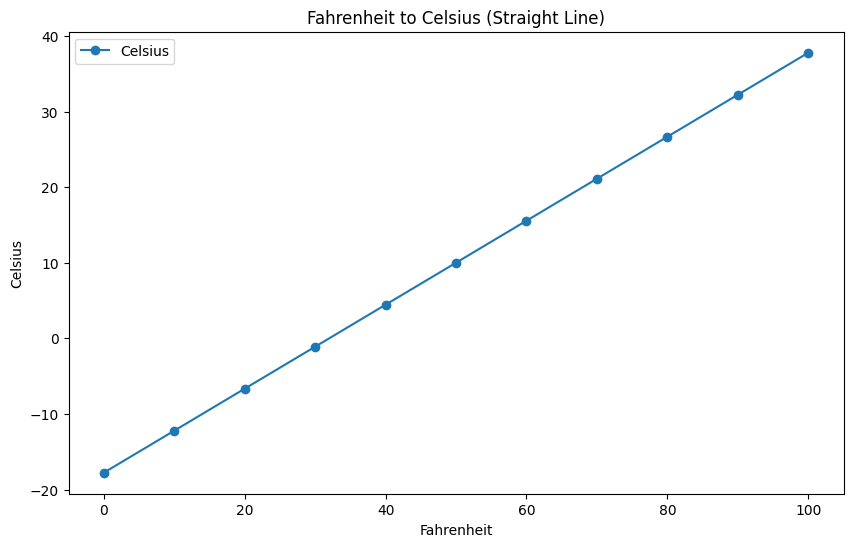

In [20]:
ax = temps_df.plot(x="Fahrenheit", y="Celsius", style="o-")
ax.set_xlabel("Fahrenheit")
ax.set_ylabel("Celsius")
ax.set_title("Fahrenheit to Celsius (Straight Line)")
plt.show()

In [21]:
print("cwd =", Path.cwd())
print("has temps_df =", "temps_df" in globals())

cwd = c:\Repos\datafun-07-ml\notebooks
has temps_df = True


## Part 2 - Prediction

We use NYC January average high temperature data and build a simple linear regression model using SciPy's `linregress`.

### Section 1 - Data Acquisition

Load NYC January high temperature data from a CSV into a pandas DataFrame.

In [22]:
# Section 1 - Data Acquisition


def find_project_root(start: Path) -> Path:
    """Find the repository root by searching upward for pyproject.toml or .git."""
    for folder in (start, *start.parents):
        if (folder / "pyproject.toml").exists() or (folder / ".git").exists():
            return folder
    raise FileNotFoundError(
        "Project root not found (missing pyproject.toml/.git in parent folders)."
    )


project_root = find_project_root(Path.cwd())
csv_path = project_root / "data" / "raw" / "ave_hi_nyc_jan_1895-2018.csv"

nyc_df = pd.read_csv(csv_path)
nyc_df.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


### Section 2 - Data Inspection

In [23]:
nyc_df.head()
nyc_df.tail()
nyc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     124 non-null    int64  
 1   Value    124 non-null    float64
 2   Anomaly  124 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.0 KB


### Section 3 - Data Cleaning

In [24]:
nyc_df = nyc_df.rename(
    columns={"Date": "date", "Value": "avg_high", "Anomaly": "anomaly"}
)
nyc_df["year"] = (nyc_df["date"] // 100).astype(int)

nyc_clean = (
    nyc_df[["year", "avg_high"]].dropna().sort_values("year").reset_index(drop=True)
)

nyc_clean.head()

,year,avg_high
0,1895,34.2
1,1896,34.7
2,1897,35.5
3,1898,39.6
4,1899,36.4


### Section 4 - Descriptive Statistics

In [25]:
nyc_clean.describe()

,year,avg_high
count,124.00,124.00
mean,1956.50,37.60
std,35.94,4.54
min,1895.00,26.10
25%,1925.75,34.58
50%,1956.50,37.60
75%,1987.25,40.60
max,2018.00,47.60


### Section 5 - Build the Model (SciPy)

In [26]:
x = nyc_clean["year"]
y = nyc_clean["avg_high"]

result = linregress(x, y)
slope = result.slope
intercept = result.intercept

print(f"slope: {slope:.6f}")
print(f"intercept: {intercept:.6f}")
print(f"r-value: {result.rvalue:.6f}")

slope: 0.014771
intercept: 8.694993
r-value: 0.116938


### Section 6 - Predict

In [27]:
year_to_predict = 2024
pred_2024_scipy = slope * year_to_predict + intercept
print(f"Predicted NYC January avg high for {year_to_predict}: {pred_2024_scipy:.2f}°F")

Predicted NYC January avg high for 2024: 38.59°F


### Section 7 - Visualization

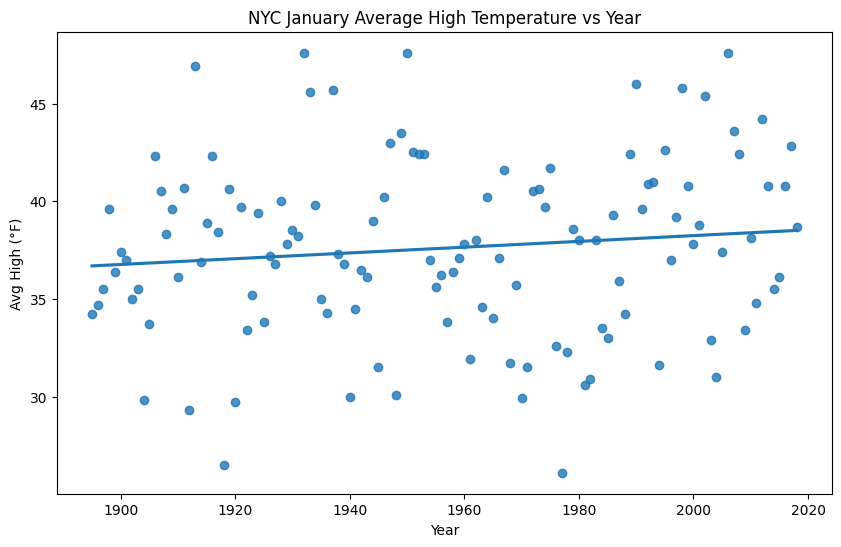

In [28]:
sns.regplot(x="year", y="avg_high", data=nyc_clean, ci=None)
plt.title("NYC January Average High Temperature vs Year")
plt.xlabel("Year")
plt.ylabel("Avg High (°F)")
plt.show()